# Data Preprocessing and Feature Selection

In this notebook, raw customer data is transformed into a machine-learning-ready format.

Steps performed:

1. Data cleaning
2. Missing value handling
3. Removing unnecessary features
4. Categorical feature encoding
5. Feature scaling
6. Train-test split
7. Feature Selection

Feature selection methods:

- Correlation based filtering
- Random Forest Feature Importance

The goal is to reduce unnecessary features while keeping the most useful churn predictors.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

The cleaned dataset from the EDA stage is loaded for preprocessing.

In [3]:
df = pd.read_csv(
    "../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)


df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

The TotalCharges column contains numeric values stored as object datatype.

It needs conversion before model training.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Check datatype before conversion
df["TotalCharges"].dtype

dtype('O')

In [11]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [12]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [13]:
df["TotalCharges"].isnull().sum()

np.int64(0)

CustomerID is only a unique identifier.

It does not contribute to churn prediction.

In [14]:
df.drop(
    "customerID",
    axis=1,
    inplace=True
)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Machine learning algorithms require numerical input.

Categorical features are converted using one-hot encoding.

In [16]:
categorical_cols = df.select_dtypes(
    include="object"
).columns


categorical_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [17]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [18]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [19]:
df_encoded.shape

(7043, 31)

The target column is separated from independent customer features.

In [20]:
X = df_encoded.drop(
    "Churn_Yes",
    axis=1
)


y = df_encoded["Churn_Yes"]

In [21]:
print(
    X.shape
)


print(
    y.shape
)

(7043, 30)
(7043,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [23]:
print(
    X_train.shape
)


print(
    X_test.shape
)

(5634, 30)
(1409, 30)


Feature scaling standardizes numerical ranges.

It is especially important for distance-based models like SVM.

In [24]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

Feature Selection Technique 1:
Correlation Based Filtering

Highly correlated or weakly related features may reduce model performance.

Correlation analysis helps identify useful features.

In [25]:
correlation = df_encoded.corr()


target_corr = abs(
    correlation["Churn_Yes"]
)


target_corr.sort_values(
    ascending=False
)

Churn_Yes                                1.000000
tenure                                   0.352229
InternetService_Fiber optic              0.308020
Contract_Two year                        0.302253
PaymentMethod_Electronic check           0.301919
InternetService_No                       0.227890
OnlineBackup_No internet service         0.227890
DeviceProtection_No internet service     0.227890
StreamingTV_No internet service          0.227890
TechSupport_No internet service          0.227890
StreamingMovies_No internet service      0.227890
OnlineSecurity_No internet service       0.227890
TotalCharges                             0.199037
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
Contract_One year                        0.177820
OnlineSecurity_Yes                       0.171226
TechSupport_Yes                          0.164674
Dependents_Yes                           0.164221
SeniorCitizen                            0.150889


In [26]:
selected_corr_features = target_corr[
    target_corr > 0.1
].index


selected_corr_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Partner_Yes', 'Dependents_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'DeviceProtection_No internet service',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service',
       'StreamingMovies_No internet service', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'Churn_Yes'],
      dtype='object')

In [27]:
selected_corr_features = selected_corr_features.drop(
    "Churn_Yes"
)

In [28]:
X_corr_selected = X[
    selected_corr_features
]

In [29]:
print(
    "Original Features:",
    X.shape[1]
)


print(
    "Correlation Selected:",
    X_corr_selected.shape[1]
)

Original Features: 30
Correlation Selected: 21


Feature Selection Technique 2:
Random Forest Feature Importance

Random Forest calculates feature importance based on how much each feature contributes to reducing classification error.

In [30]:
rf = RandomForestClassifier(
    random_state=42
)


rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":rf.feature_importances_
    }
)


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
3,TotalCharges,0.192096
1,tenure,0.174733
2,MonthlyCharges,0.168413
28,PaymentMethod_Electronic check,0.038771
10,InternetService_Fiber optic,0.038641
25,Contract_Two year,0.030176
4,gender_Male,0.028321
13,OnlineSecurity_Yes,0.028191
26,PaperlessBilling_Yes,0.025617
5,Partner_Yes,0.023326


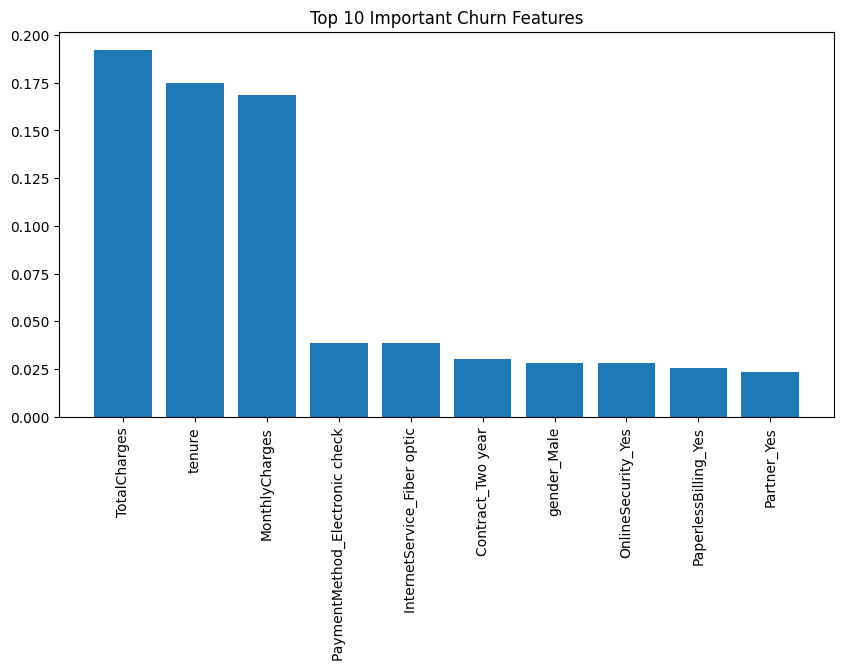

In [33]:
plt.figure(
    figsize=(10,5)
)


plt.bar(
    importance["Feature"][:10],
    importance["Importance"][:10]
)


plt.xticks(
    rotation=90
)


plt.title(
    "Top 10 Important Churn Features"
)


plt.show()

In [34]:
top_features = importance[
    "Feature"
][:15]


X_rf_selected = X[
    top_features
]

In [35]:
feature_summary = pd.DataFrame(
    
    {
        "Method":
        [
            "Original",
            "Correlation",
            "Random Forest"
        ],
        
        "Feature Count":
        [
            X.shape[1],
            X_corr_selected.shape[1],
            X_rf_selected.shape[1]
        ]
    }
)


feature_summary

,Method,Feature Count
0,Original,30
1,Correlation,21
2,Random Forest,15


In [36]:
X.to_csv(
    "../processed_data/full_features.csv",
    index=False
)


X_rf_selected.to_csv(
    "../processed_data/selected_features.csv",
    index=False
)


y.to_csv(
    "../processed_data/target.csv",
    index=False
)